## Error bars
- with error bars we can find the error in our dat

C:\Users\ahmad\AppData\Local\Temp\ipykernel_12676\513442207.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


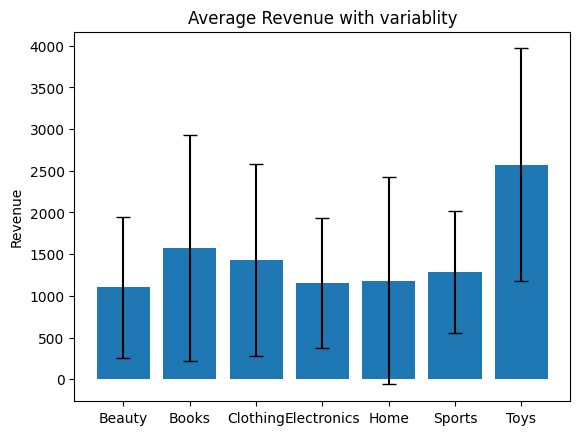

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv('ecommerce_dataset.csv',parse_dates=['order_date'])

stats=df.groupby("product_category")['revenue'].agg(['mean','std'])

figure,ax=plt.subplots()
ax.bar(stats.index,stats['mean'],yerr=stats['std'],capsize=5)

ax.set_title("Average Revenue with variablity")
ax.set_ylabel("Revenue")
figure.show()

## monnthly revenue

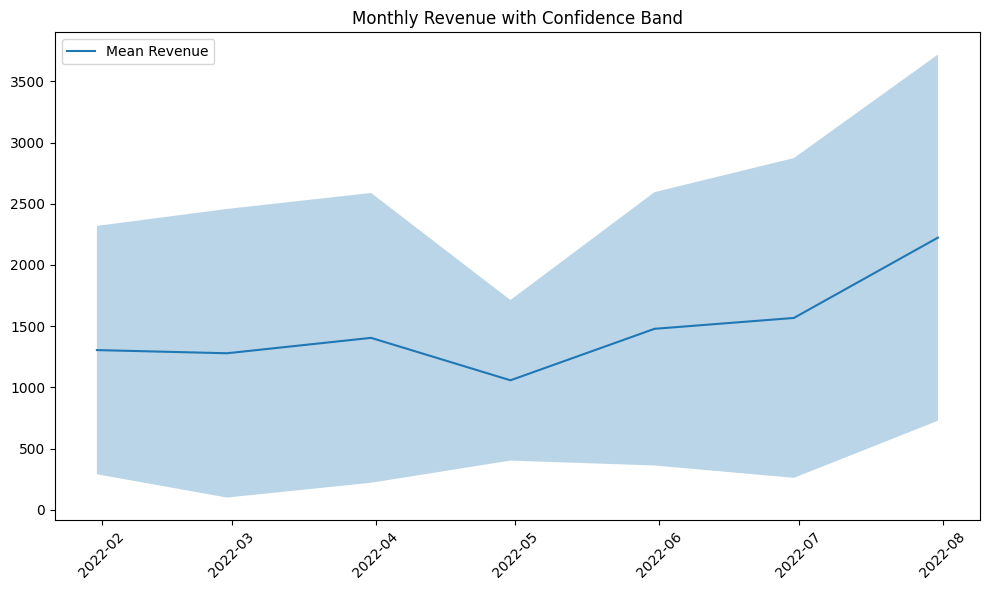

In [10]:
monthly = (
    df.set_index("order_date")["revenue"]
    .resample("ME")
    .agg(["mean", "std"])
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly.index, monthly["mean"], label="Mean Revenue")

ax.fill_between(
    monthly.index,
    monthly["mean"] - monthly["std"],
    monthly["mean"] + monthly["std"],
    alpha=0.3
)

ax.tick_params(axis="x", rotation=45)
ax.set_title("Monthly Revenue with Confidence Band")
ax.legend()

plt.tight_layout()
plt.show()